In [1]:
import json
import sys
import os

import pandas as pd

sys.path.append(os.path.abspath(".."))

# import top 25 CWEs
with open("../data/raw/top_25_cwe_data.json", "r", encoding="utf-8") as f:
    cwe_data = json.load(f)

TOP_25_CWES = cwe_data["TOP_25_CWES"]

# build CWE map for TOSEM
with open("../data/raw/tool_assisted_manual_dataset.json") as f:
    dataset = json.load(f)

rows = []
for entry in dataset:
    cwe = entry.get("cwe", "Unknown")
    for commit in entry.get("fixing", []):
        rows.append({"commit_id": commit, "cwe": cwe})
    intro = entry.get("introducing")
    if intro:
        rows.append({"commit_id": intro, "cwe": cwe})

df_cwe_map = pd.DataFrame(rows)

# merge to get CWEs
df_tosem = pd.read_csv("../data/intermediate/churn_tosem.csv")
df_tosem = df_tosem.merge(df_cwe_map, on="commit_id", how="left")

df_tosem_filtered = df_tosem[df_tosem["cwe"].isin(TOP_25_CWES)]

In [2]:
import pandas as pd
import ast

# Load both
df_icvul = pd.read_csv("../data/intermediate/churn_icvul_repo_restricted.csv")
df_icvul_raw = pd.read_csv("../data/raw/icvul.csv")

# fc_hash lookup
fc_lookup = df_icvul_raw[["fc_hash", "cwe_id"]].rename(columns={"fc_hash": "commit_id"})

# vcc_hash lookup
df_icvul_raw["vcc_hash"] = df_icvul_raw["vcc_hash"].apply(ast.literal_eval)
vcc_lookup = df_icvul_raw.explode("vcc_hash")[["vcc_hash", "cwe_id"]].rename(columns={"vcc_hash": "commit_id"})

# Combine both lookups
commit_to_cwe = pd.concat([fc_lookup, vcc_lookup]).drop_duplicates(subset="commit_id")

# Merge into processed ICVul df
df_icvul = df_icvul.merge(commit_to_cwe, on="commit_id", how="left")

# Filter to top 25
df_icvul_filtered = df_icvul[df_icvul["cwe_id"].isin(TOP_25_CWES)]
df_icvul_filtered = df_icvul_filtered.rename(columns={"cwe_id": "cwe"})

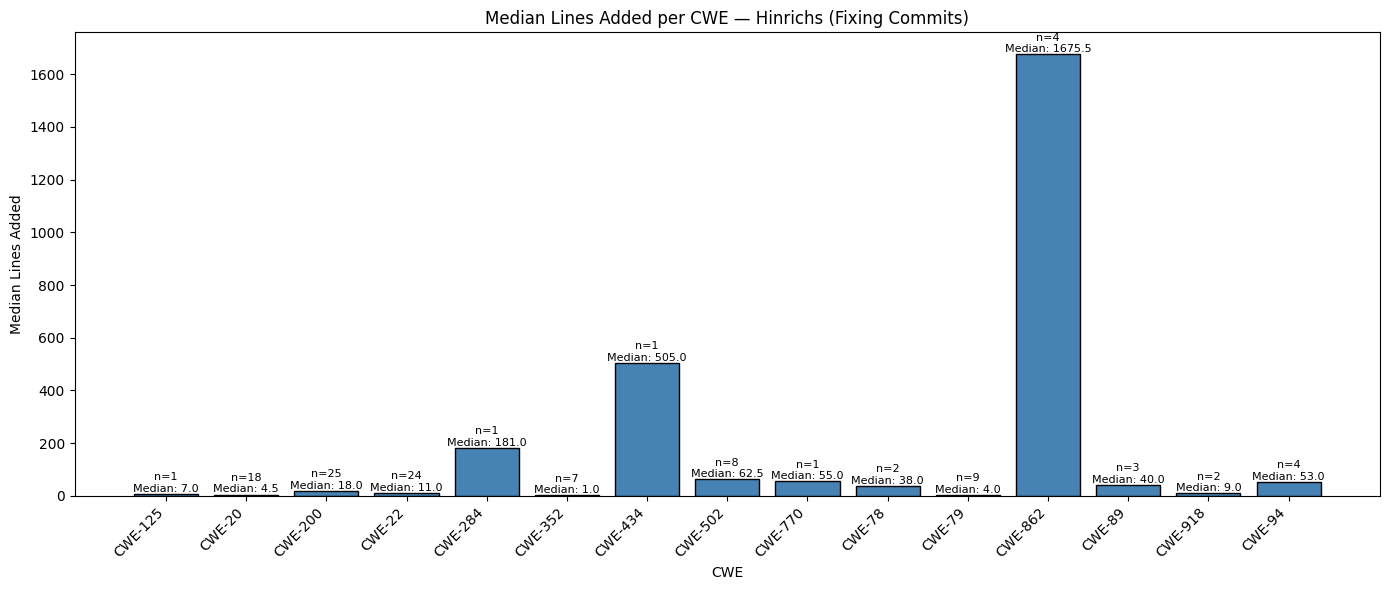

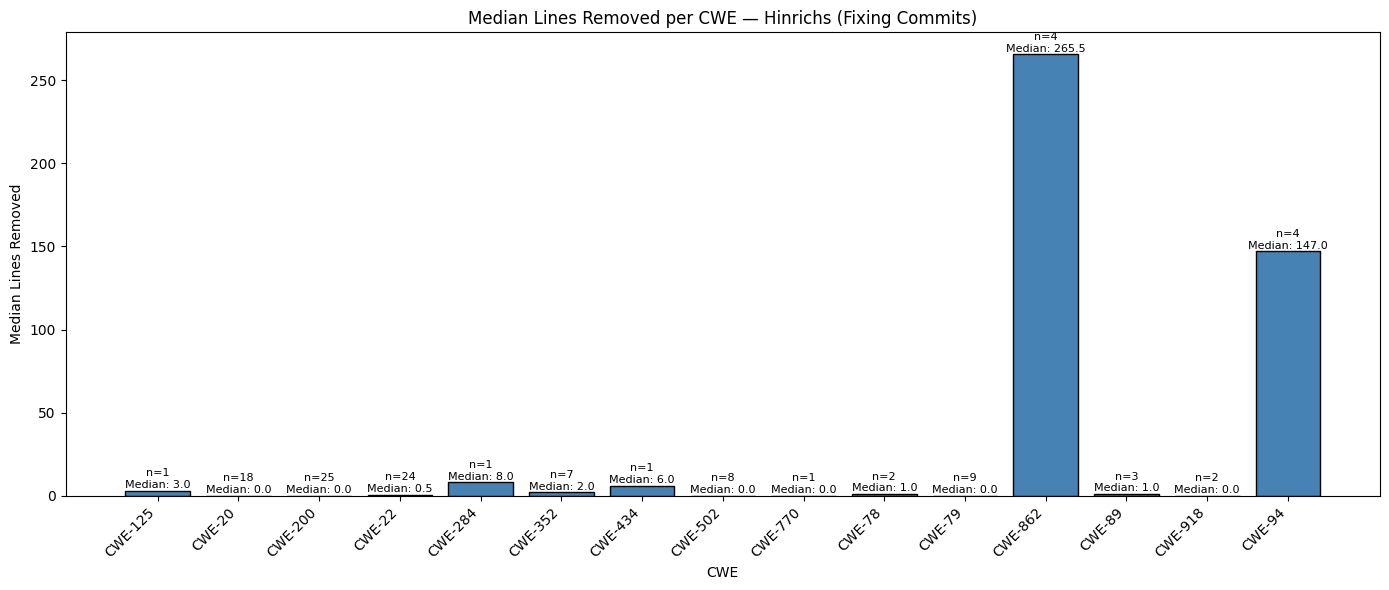

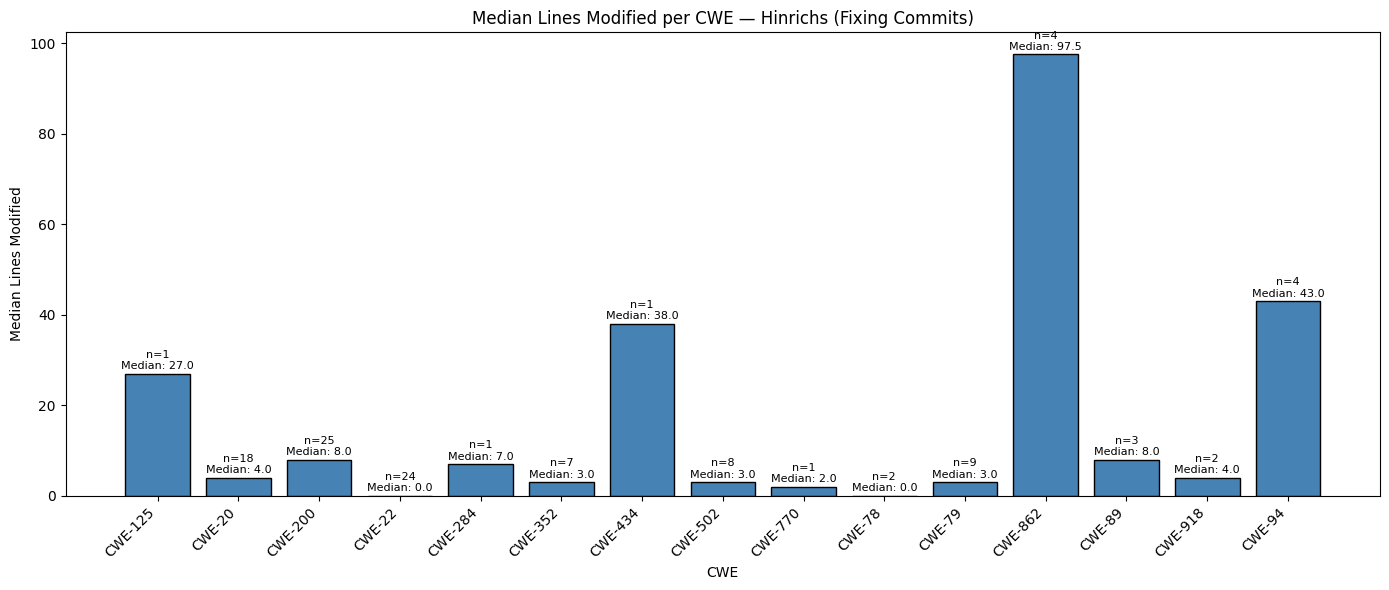

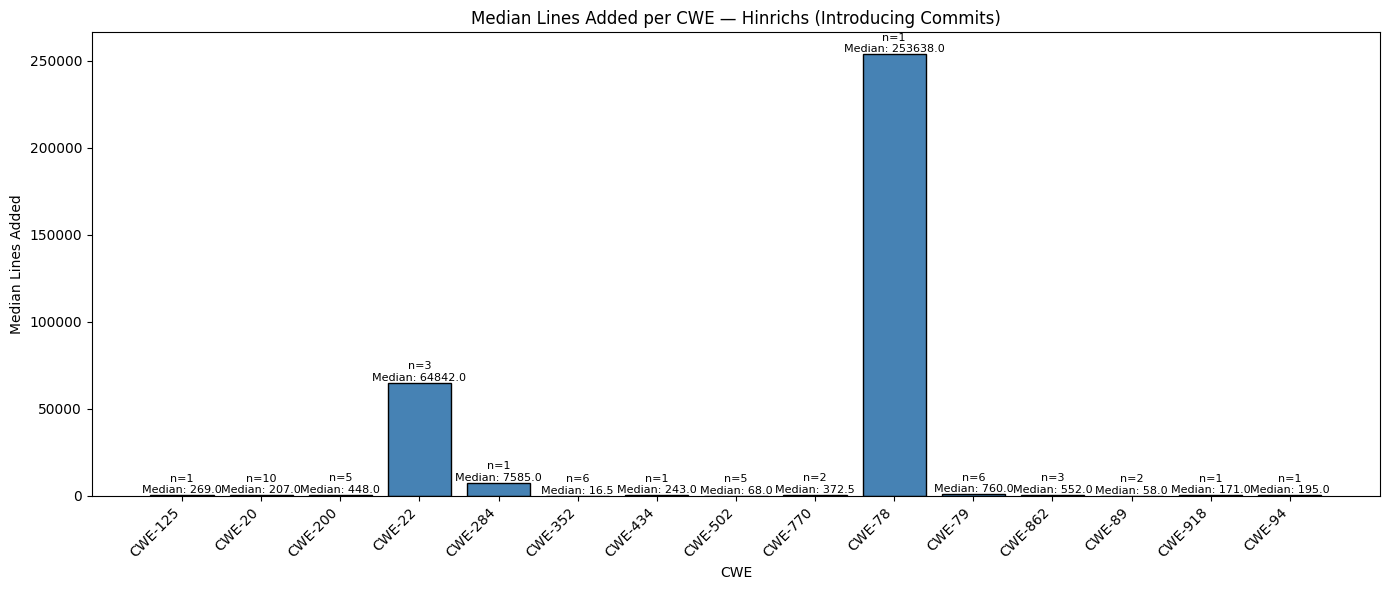

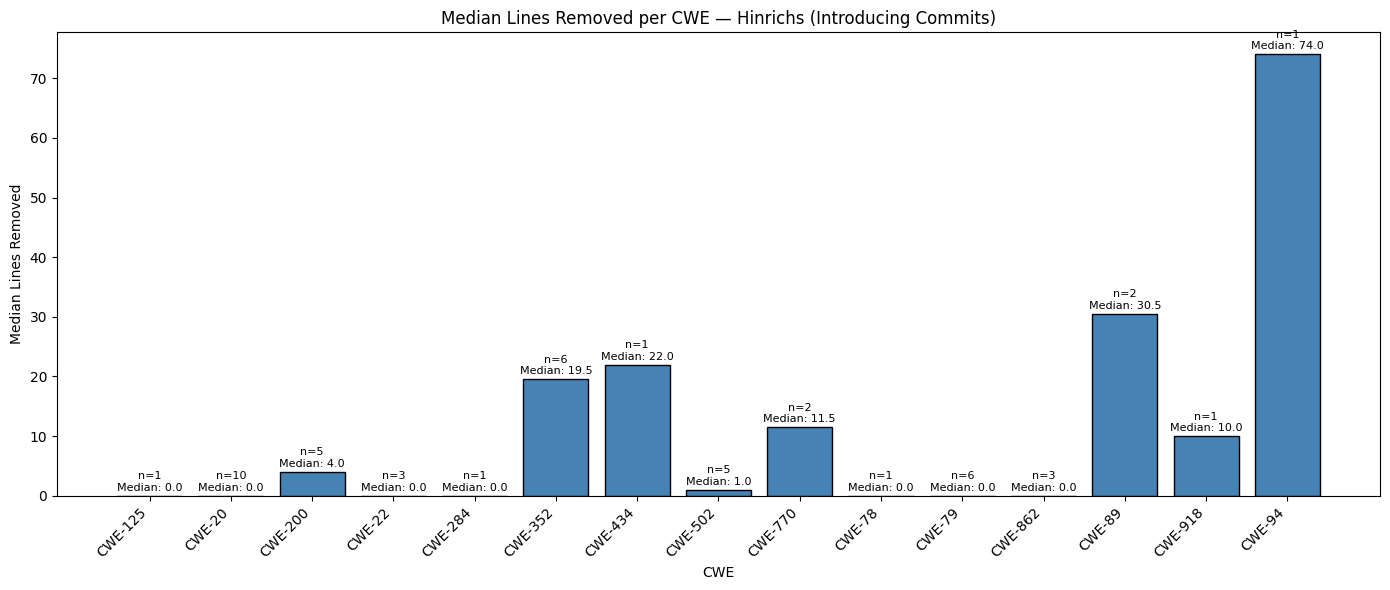

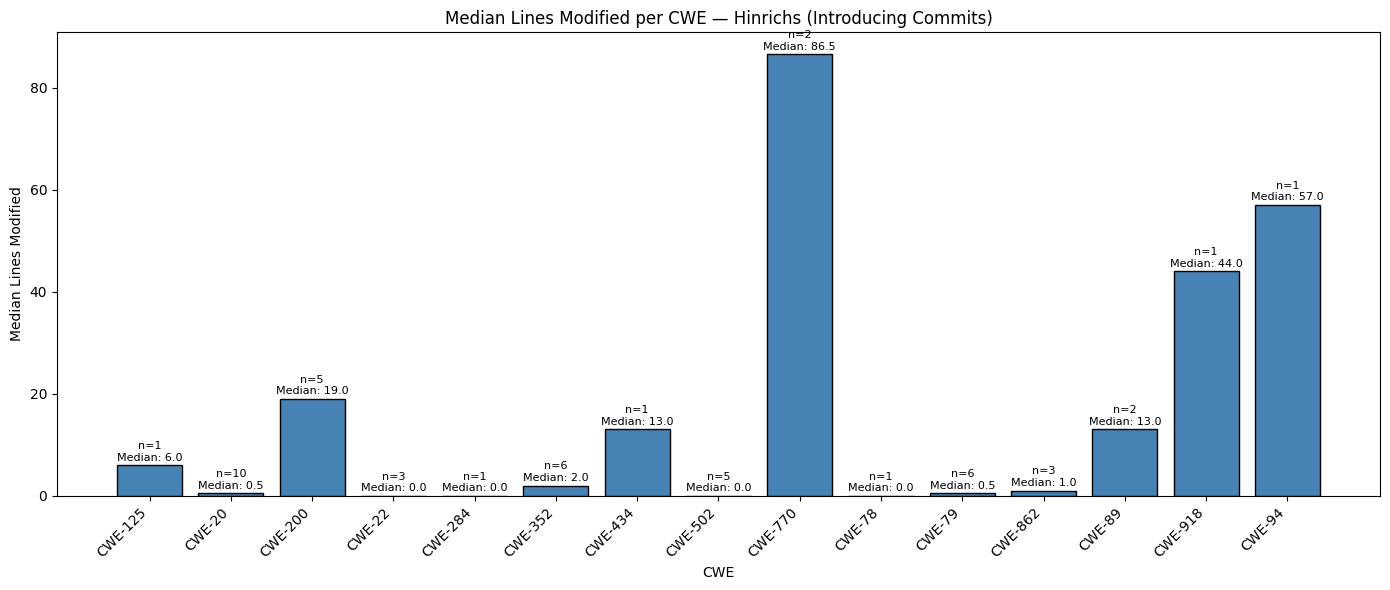

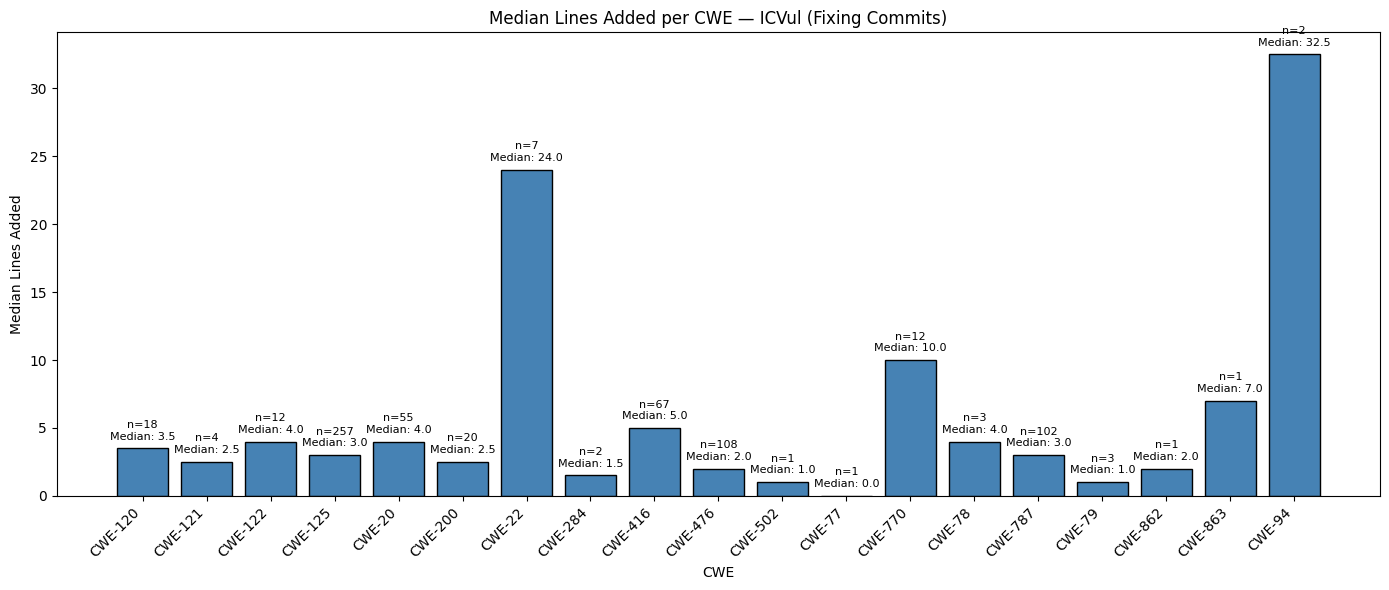

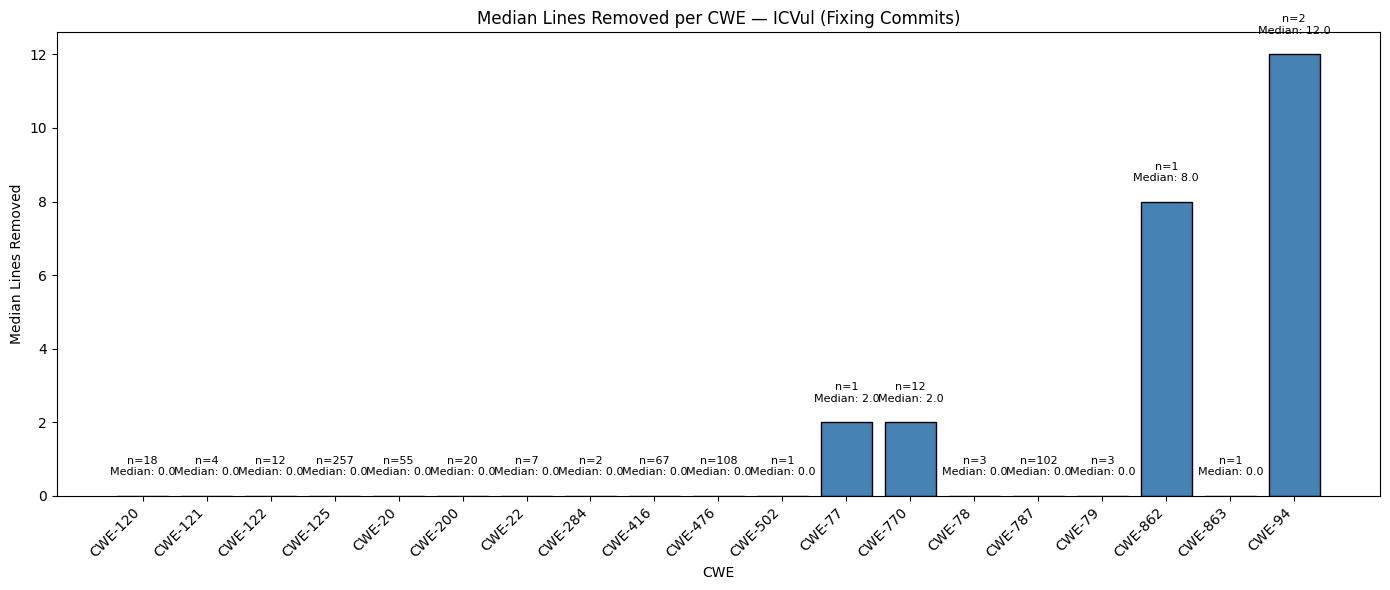

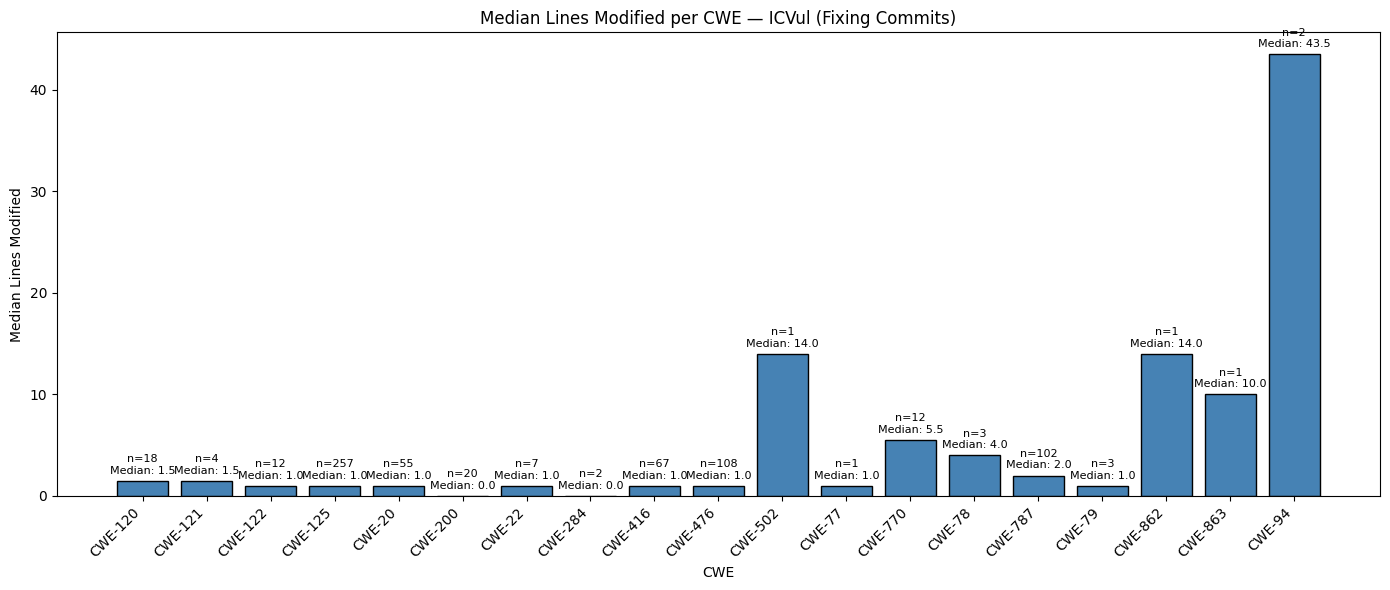

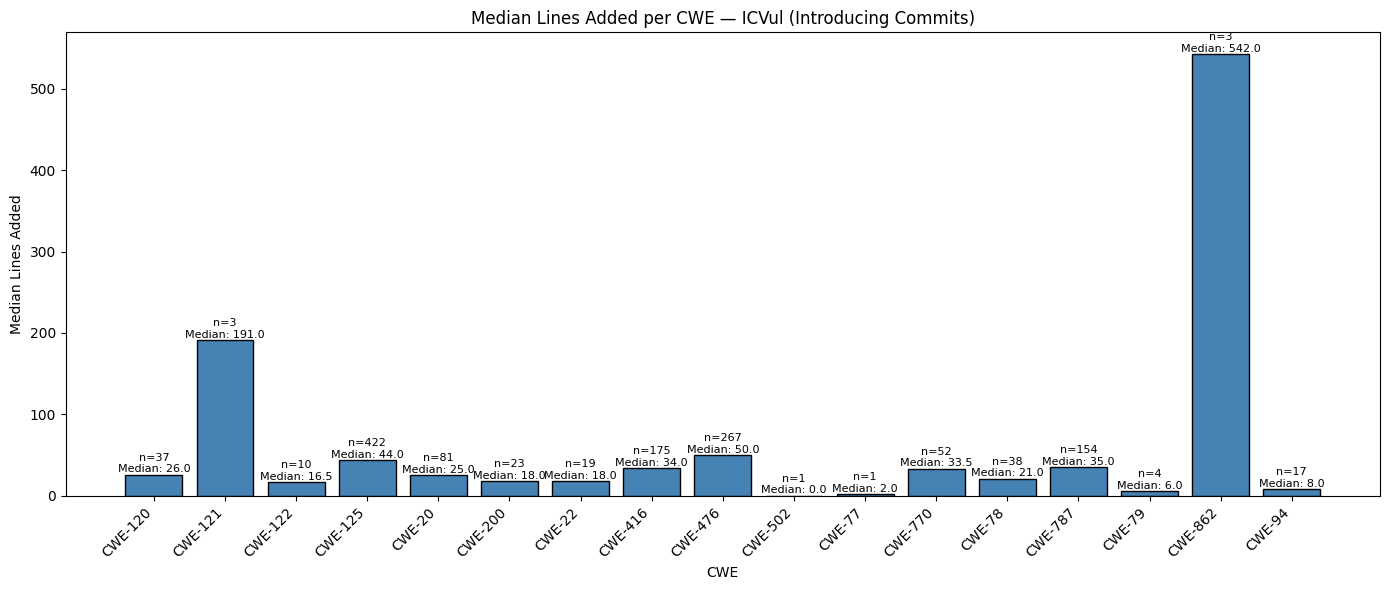

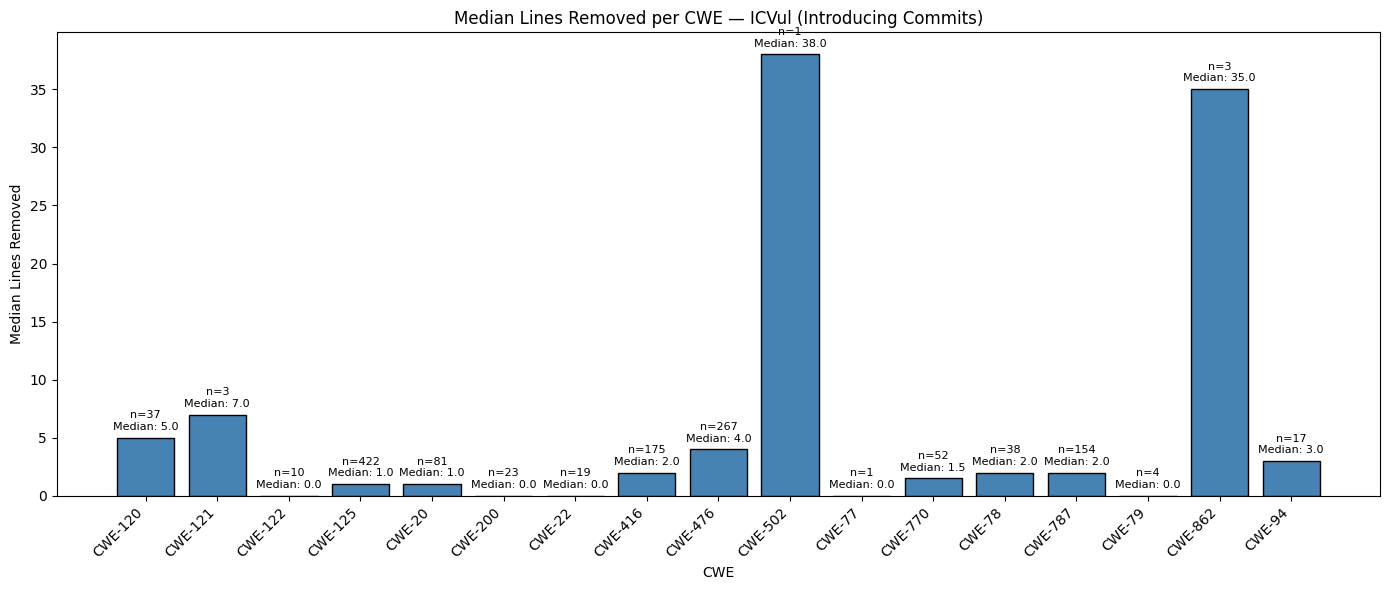

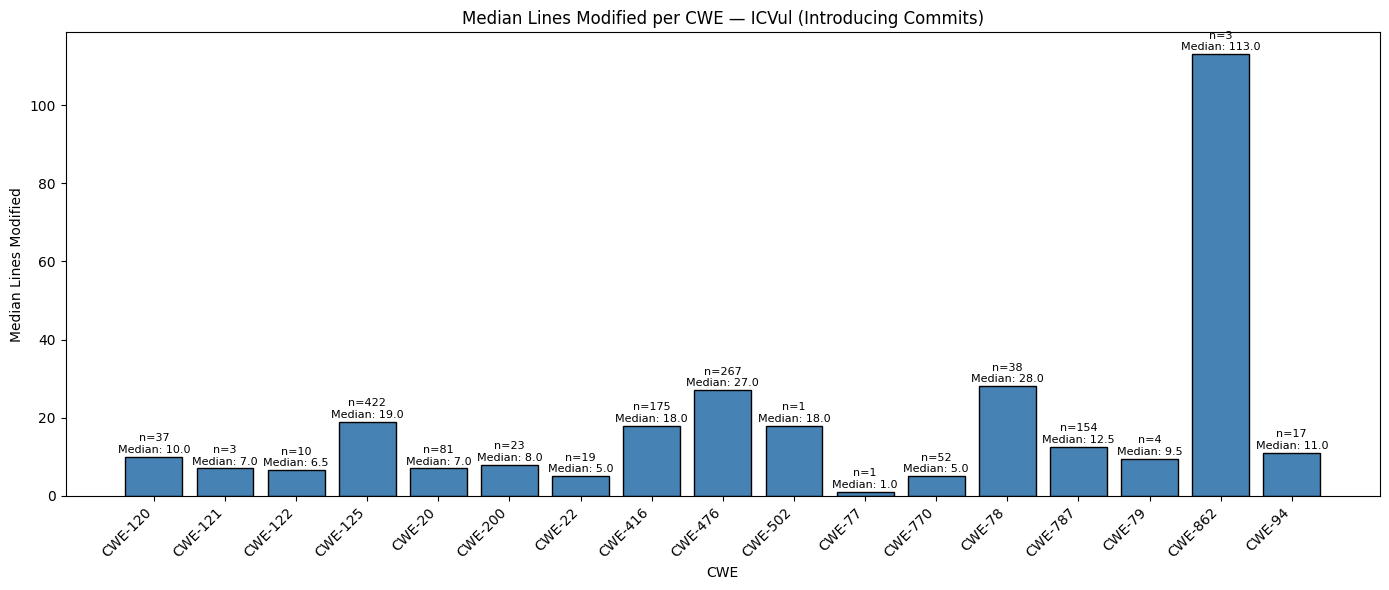

In [3]:
from utils.plot import plot_cwe_median

# TOSEM
plot_cwe_median(df_tosem_filtered, "Hinrichs", "VFC")
plot_cwe_median(df_tosem_filtered, "Hinrichs", "VIC")

# ICVul
plot_cwe_median(df_icvul_filtered, "ICVul", "VFC")
plot_cwe_median(df_icvul_filtered, "ICVul", "VIC")